# Epidemic Outbreak Trajectory Visualization

This notebook visualizes the dynamics of epidemic simulations from BEAST2 outputs.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import os

notebook_dir = Path(os.getcwd())
utils_dir = notebook_dir.parent / 'utils'

# Add to path if not already there
if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Import our utility functions
from trajectory_utils import (
    create_species_name,
    load_trajectory_wide,
    get_compartment_groups,
    get_sample_data
)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print(f"✓ Imports successful!")
print(f"✓ Utils loaded from: {utils_dir}")

✓ Imports successful!
✓ Utils loaded from: /Users/lukelyu/Library/CloudStorage/OneDrive-Emory/emory/phyloGNN/utils


## Load Data

In [2]:
# Load trajectory data
TRAJ_FILE = '/Users/lukelyu/Desktop/out/1_beast2.traj'
print("Loading trajectory data...")
df_wide = load_trajectory_wide(TRAJ_FILE)
print(f"✓ Loaded {len(df_wide)} time points across {df_wide['Sample'].nunique()} simulations")

Loading trajectory data...
✓ Loaded 1068812 time points across 10 simulations


In [3]:
# Extract data for specific sample
SAMPLE_ID = 1
sample_data = get_sample_data(df_wide, SAMPLE_ID)
print(f"Extracted simulation {SAMPLE_ID}: {len(sample_data)} time points")

# Get compartment groups
groups = get_compartment_groups(sample_data)
print(f"\nCompartments:")
print(f"  S compartments: {len(groups['S'])}")
print(f"  I compartments: {len(groups['I'])}")
print(f"  R compartment: {len(groups['R'])}")
print(f"  Sample compartment: {len(groups['sample'])}")

Extracted simulation 1: 106588 time points

Compartments:
  S compartments: 10
  I compartments: 10
  R compartment: 1
  Sample compartment: 1


## Preview Data

In [4]:
# Show first few rows
display(sample_data.head(20))

species,Sample,t,I[0],I[1],I[2],I[3],I[4],I[5],I[6],I[7],...,S[1],S[2],S[3],S[4],S[5],S[6],S[7],S[8],S[9],sample
0,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5675.0,0.0
1,1,1.962281,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5674.0,0.0
2,1,16.308955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5673.0,0.0
3,1,18.231273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5673.0,0.0
4,1,26.622157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5672.0,0.0
5,1,27.931941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5672.0,0.0
6,1,31.280904,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5671.0,0.0
7,1,32.445225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5670.0,0.0
8,1,32.470224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5669.0,0.0
9,1,32.984784,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4484.0,5005.0,8678.0,6388.0,7586.0,1222.0,1728.0,5250.0,5668.0,0.0


## Visualization

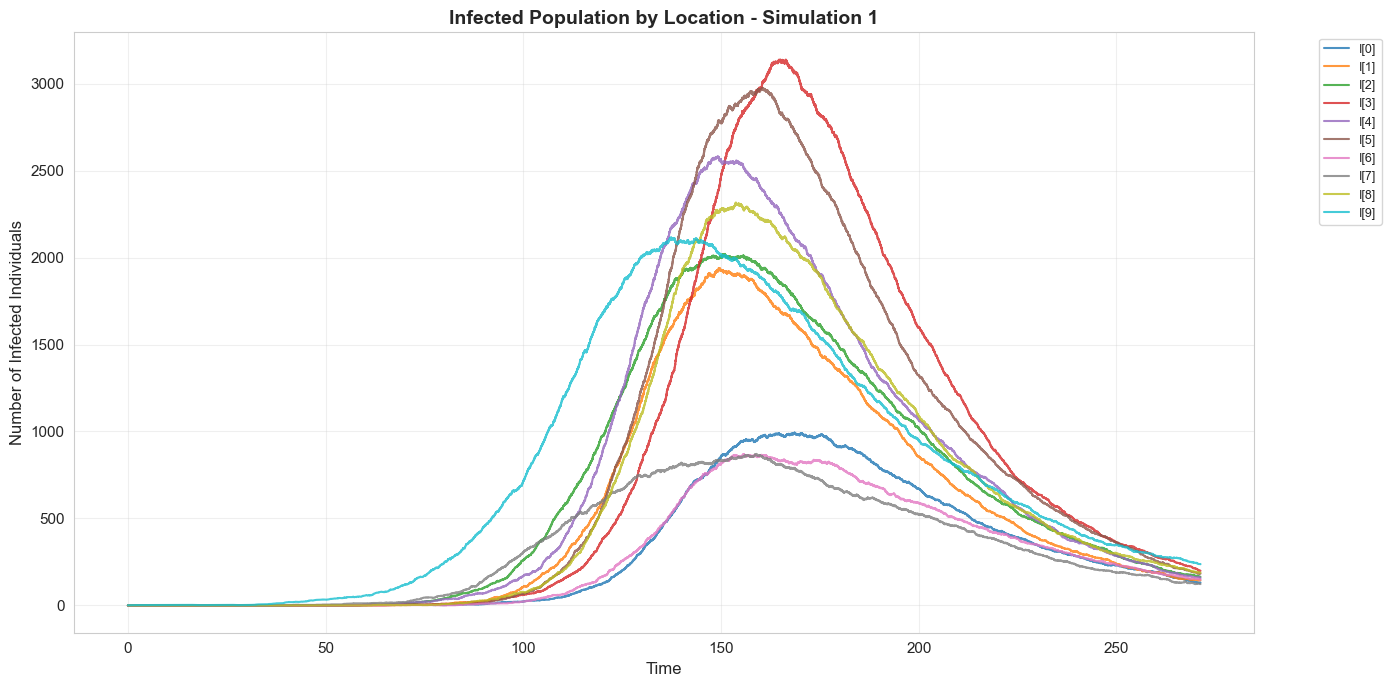

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each infected compartment
for i_comp in groups['I']:
    ax.plot(sample_data['t'], sample_data[i_comp], label=i_comp, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Number of Infected Individuals', fontsize=12)
ax.set_title(f'Infected Population by Location - Simulation {SAMPLE_ID}', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

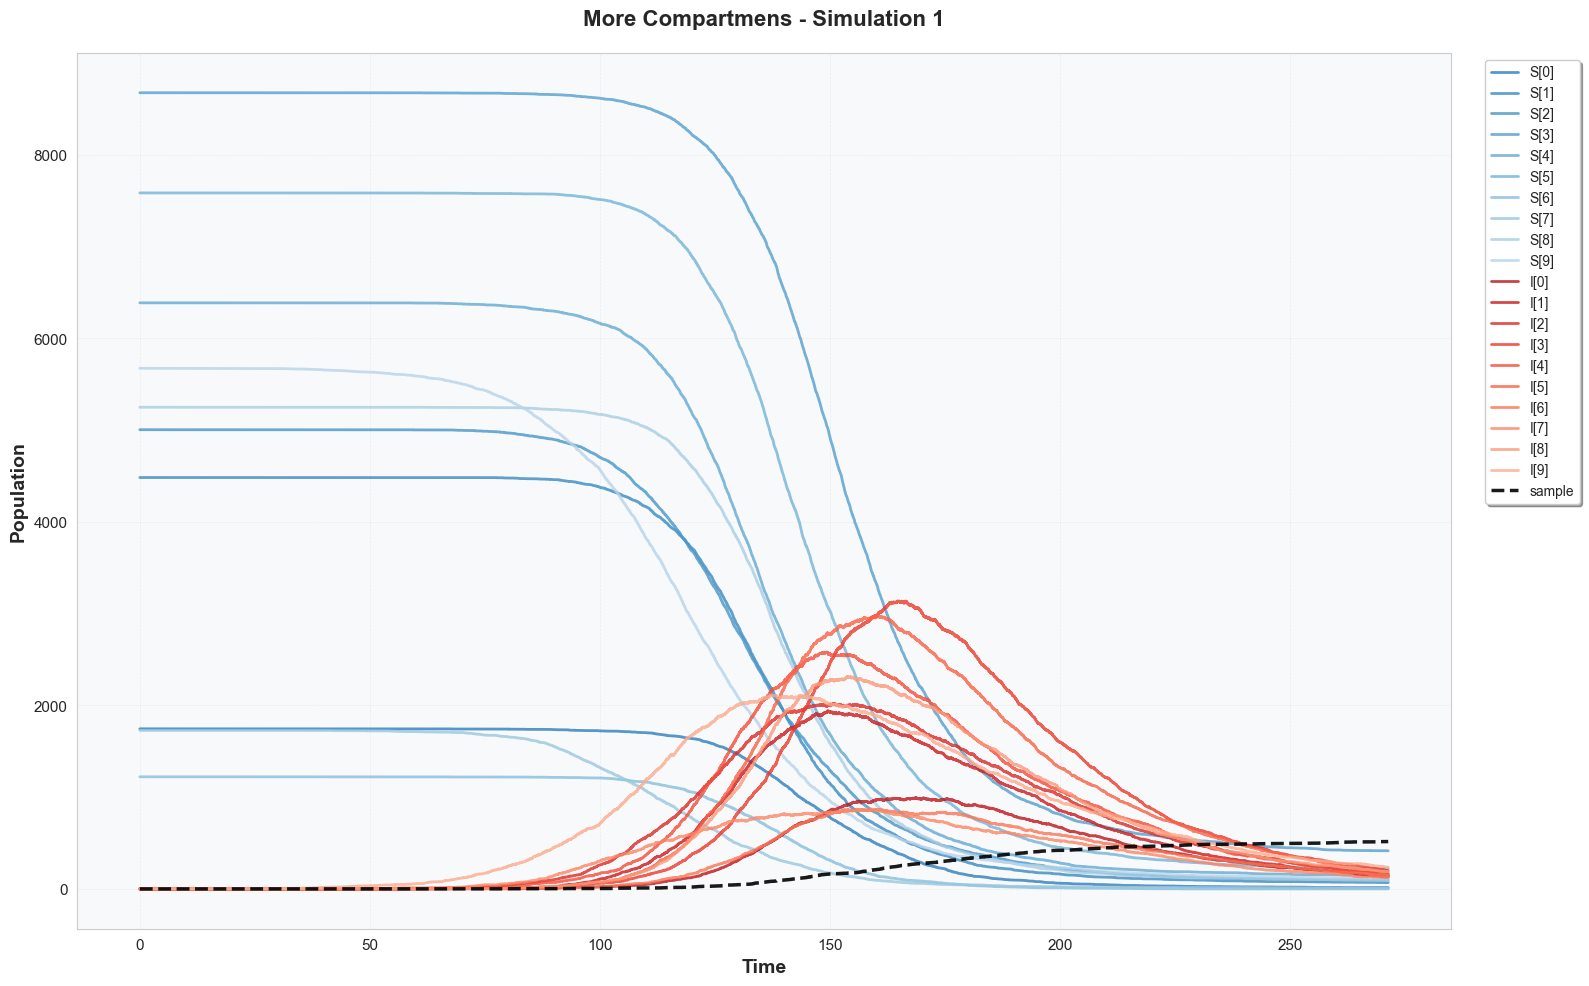

In [6]:
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(16, 10))

# Generate color gradients
num_s = len(groups['S'])
num_i = len(groups['I'])

# Blues for S compartments (dark to light)
# Using a custom blue palette: from deep navy to light sky blue
blues = plt.cm.Blues(np.linspace(0.7, 0.3, num_s))  # Reversed to go dark to light

# Reds for I compartments (dark to light)
# Using a custom red palette: from dark crimson to light coral
reds = plt.cm.Reds(np.linspace(0.8, 0.3, num_i))  # Reversed to go dark to light

# Plot Susceptible compartments in blue shades
for idx, s_comp in enumerate(groups['S']):
    ax.plot(sample_data['t'], sample_data[s_comp], 
            label=s_comp, 
            color=blues[idx], 
            linewidth=2, 
            alpha=0.8)

# Plot Infected compartments in red shades
for idx, i_comp in enumerate(groups['I']):
    ax.plot(sample_data['t'], sample_data[i_comp], 
            label=i_comp, 
            color=reds[idx], 
            linewidth=2, 
            alpha=0.8)

# Plot Sample in black
if groups['sample']:
    ax.plot(sample_data['t'], sample_data['sample'], 
            label='sample', 
            color='#000000',  # Black
            linewidth=2.5, 
            alpha=0.9,
            linestyle='--')  # Dashed line for distinction

# Styling
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Population', fontsize=14, fontweight='bold')
ax.set_title(f'More Compartmens - Simulation {SAMPLE_ID}', 
             fontsize=16, fontweight='bold', pad=20)

# Create custom legend with sections
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          fontsize=10,
          ncol=1,
          frameon=True,
          fancybox=True,
          shadow=True)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_facecolor('#f8f9fa')  # Light gray background

plt.tight_layout()
plt.show()
